In [2]:
import pandas as pd

# Load kedua file
df_mar = pd.read_parquet(r"C:\Users\HP VICTUS\Downloads\yellow_tripdata_2026-03.parquet")
df_apr = pd.read_parquet(r"C:\Users\HP VICTUS\Downloads\yellow_tripdata_2026-04.parquet")

# Gabungkan
df = pd.concat([df_mar, df_apr], ignore_index=True)

print("Shape gabungan:", df.shape)
print("\nKolom:", df.columns.tolist())
print("\nInfo:")
df.info()

Shape gabungan: (7753115, 20)

Kolom: ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee', 'cbd_congestion_fee']

Info:
<class 'pandas.DataFrame'>
RangeIndex: 7753115 entries, 0 to 7753114
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     str           
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int

simpan ke bronze folder

In [3]:
# Simpan ke bronze
df.to_parquet(r"C:\Users\HP VICTUS\nyc-taxi-abd\data\bronze\yellow_tripdata_2026-03-04.parquet", index=False)

print("✅ Data tersimpan di Bronze layer!")
print("\nMissing values per kolom:")
print(df.isnull().sum())

✅ Data tersimpan di Bronze layer!

Missing values per kolom:
VendorID                       0
tpep_pickup_datetime           0
tpep_dropoff_datetime          0
passenger_count          1745534
trip_distance                  0
RatecodeID               1745534
store_and_fwd_flag       1745534
PULocationID                   0
DOLocationID                   0
payment_type                   0
fare_amount                    0
extra                          0
mta_tax                        0
tip_amount                     0
tolls_amount                   0
improvement_surcharge          0
total_amount                   0
congestion_surcharge     1745534
Airport_fee              1745534
cbd_congestion_fee             0
dtype: int64


bikin processing data di silver data

In [4]:
# ===== SILVER LAYER =====

df_silver = df.copy()

# 1. Hitung trip_duration (menit)
df_silver['trip_duration'] = (
    df_silver['tpep_dropoff_datetime'] - df_silver['tpep_pickup_datetime']
).dt.total_seconds() / 60

# 2. Drop missing values
df_silver = df_silver.dropna(subset=['passenger_count', 'RatecodeID', 'store_and_fwd_flag'])

# 3. Filter data tidak valid
df_silver = df_silver[df_silver['trip_duration'] > 1]        # min 1 menit
df_silver = df_silver[df_silver['trip_duration'] < 180]      # max 3 jam
df_silver = df_silver[df_silver['trip_distance'] > 0]        # jarak harus > 0
df_silver = df_silver[df_silver['fare_amount'] > 0]          # tarif harus > 0
df_silver = df_silver[df_silver['passenger_count'] > 0]      # penumpang > 0

# 4. Feature engineering
df_silver['pickup_hour'] = df_silver['tpep_pickup_datetime'].dt.hour
df_silver['pickup_day'] = df_silver['tpep_pickup_datetime'].dt.dayofweek
df_silver['pickup_month'] = df_silver['tpep_pickup_datetime'].dt.month
df_silver['is_rush_hour'] = df_silver['pickup_hour'].apply(
    lambda x: 1 if (7 <= x <= 9) or (17 <= x <= 19) else 0
)

print("Shape setelah cleaning:", df_silver.shape)
print("\nSample data:")
df_silver[['trip_duration', 'trip_distance', 'pickup_hour', 'pickup_day', 'is_rush_hour']].head()

Shape setelah cleaning: (5790710, 25)

Sample data:


,trip_duration,trip_distance,pickup_hour,pickup_day,is_rush_hour
0,11.316667,2.58,0,6,0
1,8.800000,1.50,0,6,0
2,7.866667,0.88,0,6,0
3,12.150000,1.76,0,6,0
4,9.950000,1.57,0,6,0


Silver layer beres! Dari 7.7 juta jadi 5.7 juta baris setelah cleaning

Sekarang simpan ke Silver lalu lanjut EDA.

✅ Data tersimpan di Silver layer!


Matplotlib is building the font cache; this may take a moment.


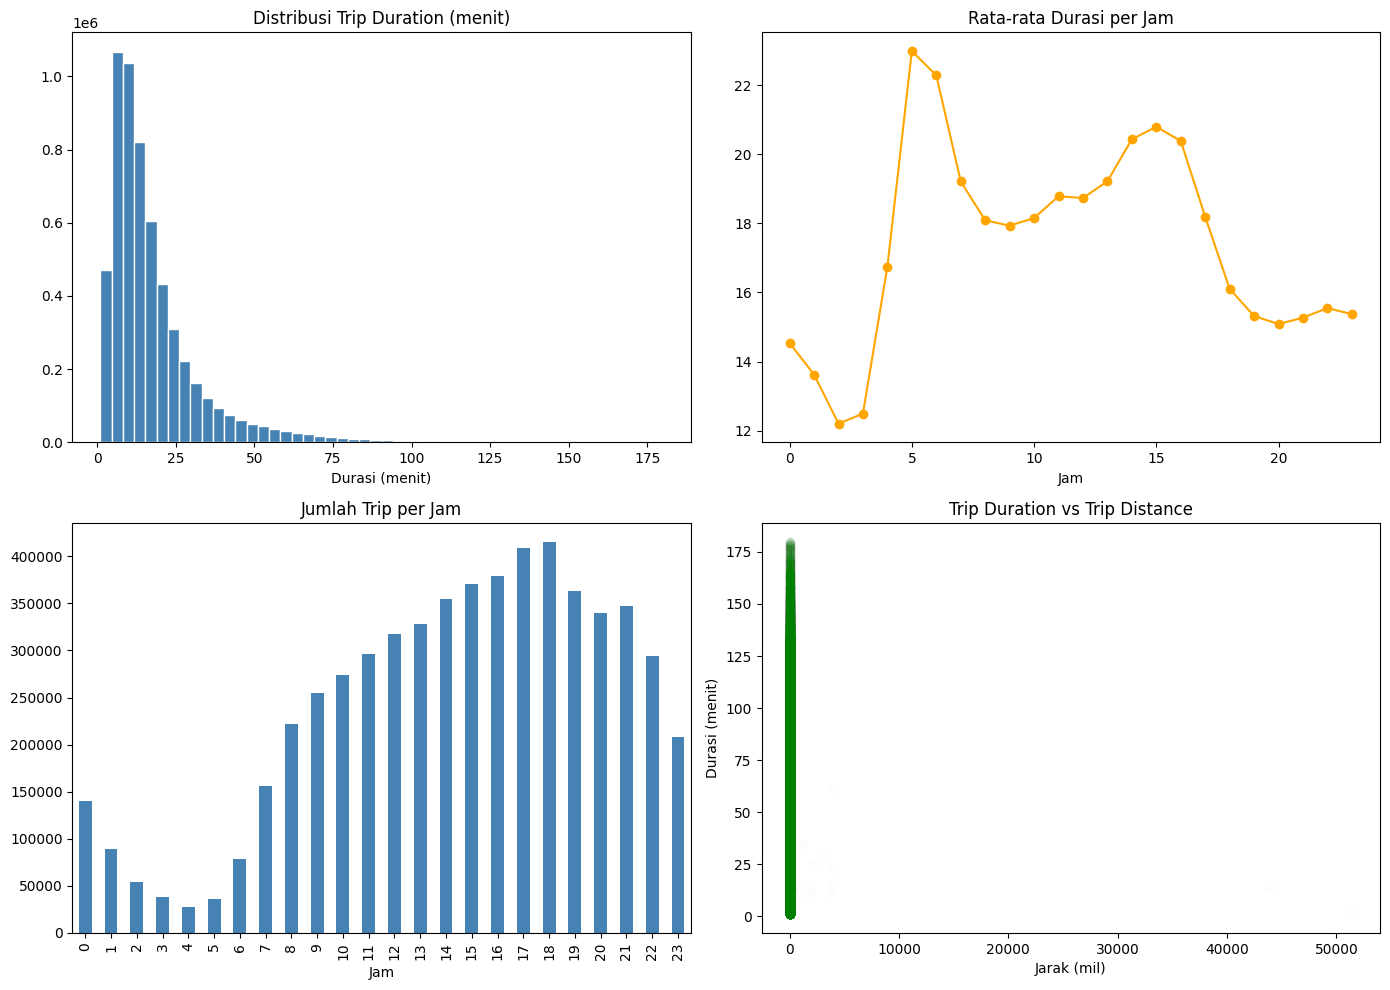

✅ Plot tersimpan!


In [5]:
# Simpan ke Silver
df_silver.to_parquet(r"C:\Users\HP VICTUS\nyc-taxi-abd\data\silver\yellow_tripdata_silver.parquet", index=False)
print("✅ Data tersimpan di Silver layer!")

# ===== EDA =====
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribusi durasi perjalanan
axes[0,0].hist(df_silver['trip_duration'], bins=50, color='steelblue', edgecolor='white')
axes[0,0].set_title('Distribusi Trip Duration (menit)')
axes[0,0].set_xlabel('Durasi (menit)')

# 2. Durasi rata-rata per jam
df_silver.groupby('pickup_hour')['trip_duration'].mean().plot(
    ax=axes[0,1], color='orange', marker='o')
axes[0,1].set_title('Rata-rata Durasi per Jam')
axes[0,1].set_xlabel('Jam')

# 3. Jumlah trip per jam
df_silver.groupby('pickup_hour')['trip_duration'].count().plot(
    kind='bar', ax=axes[1,0], color='steelblue')
axes[1,0].set_title('Jumlah Trip per Jam')
axes[1,0].set_xlabel('Jam')

# 4. Durasi vs Jarak
axes[1,1].scatter(df_silver['trip_distance'], df_silver['trip_duration'], 
                  alpha=0.01, color='green')
axes[1,1].set_title('Trip Duration vs Trip Distance')
axes[1,1].set_xlabel('Jarak (mil)')
axes[1,1].set_ylabel('Durasi (menit)')

plt.tight_layout()
plt.savefig(r"C:\Users\HP VICTUS\nyc-taxi-abd\notebooks\eda_plot.png", dpi=150)
plt.show()
print("✅ Plot tersimpan!")

- Distribusi durasi → mayoritas perjalanan 5–25 menit, right-skewed (wajar untuk taksi kota)
- Rata-rata durasi per jam → paling lama sekitar jam 5–6 pagi (aneh, mungkin outlier) dan jam 14–15 siang
- Jumlah trip per jam → paling ramai jam 17–19 (rush hour sore), sepi dini hari
- Duration vs Distance → ada outlier ekstrem jarak >10.000 mil, perlu difilter lagi

Ada outlier parah di scatter plot kanan bawah. Tambah filter

In [6]:
# Filter outlier jarak ekstrem
df_silver = df_silver[df_silver['trip_distance'] < 50]

print("Shape setelah filter outlier jarak:", df_silver.shape)

Shape setelah filter outlier jarak: (5789826, 25)


Sekarang lanjut Gold layer + Modeling. Buat cell baru

In [7]:
# ===== GOLD LAYER =====

features = ['trip_distance', 'passenger_count', 'pickup_hour', 
            'pickup_day', 'pickup_month', 'is_rush_hour',
            'PULocationID', 'DOLocationID']

target = 'trip_duration'

df_gold = df_silver[features + [target]].dropna()

# Simpan Gold layer
df_gold.to_parquet(r"C:\Users\HP VICTUS\nyc-taxi-abd\data\gold\yellow_tripdata_gold.parquet", index=False)
print("✅ Data tersimpan di Gold layer!")
print("Shape:", df_gold.shape)

✅ Data tersimpan di Gold layer!
Shape: (5789826, 9)


modelling

In [8]:
# ===== MODELING =====
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

X = df_gold[features]
y = df_gold[target]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

# ===== BASELINE: Mean Predi

Train size: (4631860, 8)
Test size: (1157966, 8)
